In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Dataset path
dataset_path = "/content/drive/MyDrive/Oral_cancer/First Set"
normal_path = os.path.join(dataset_path, "100x Normal Oral Cavity Histopathological Images")
oscc_path = os.path.join(dataset_path, "100x OSCC Histopathological Images")

print("Normal Path Exists:", os.path.exists(normal_path))
print("OSCC Path Exists:", os.path.exists(oscc_path))

Mounted at /content/drive
Normal Path Exists: True
OSCC Path Exists: True


In [2]:
import cv2
import numpy as np

IMG_SIZE = 160

def load_images(folder, label):
    images, labels = [], []
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
    return images, labels

normal_images, normal_labels = load_images(normal_path, 0)
oscc_images, oscc_labels = load_images(oscc_path, 1)

X_normal = np.array(normal_images)
y_normal = np.array(normal_labels)
X_oscc = np.array(oscc_images)
y_oscc = np.array(oscc_labels)

print("Normal Images:", X_normal.shape)
print("OSCC Images:", X_oscc.shape)

Normal Images: (89, 160, 160, 3)
OSCC Images: (439, 160, 160, 3)


In [3]:
from imblearn.over_sampling import SMOTE

X_combined = np.concatenate((X_normal, X_oscc), axis=0)
y_combined = np.concatenate((y_normal, y_oscc), axis=0)

# Flatten for SMOTE
X_flat = X_combined.reshape((X_combined.shape[0], -1))
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_combined)

# Reshape back
X_resampled = X_resampled.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

print("Balanced Distribution:", np.bincount(y_resampled))

Balanced Distribution: [439 439]


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=32)
val_generator = datagen.flow(X_val, y_val, batch_size=32)

Train: 702 Val: 88 Test: 88


In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

def ResNet50_Classifier(input_shape=(160, 160, 3), num_classes=2):
    inputs = Input(shape=input_shape)
    base_model = ResNet50(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base model to use as feature extractor

    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


In [6]:
model = ResNet50_Classifier()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    batch_size=32
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.5440 - loss: 0.8090 - val_accuracy: 0.4659 - val_loss: 0.6930
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.5406 - loss: 0.7124 - val_accuracy: 0.5455 - val_loss: 0.6822
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5167 - loss: 0.7159 - val_accuracy: 0.5114 - val_loss: 0.6854
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.5531 - loss: 0.6959 - val_accuracy: 0.5341 - val_loss: 0.6859
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.4846 - loss: 0.7362 - val_accuracy: 0.4659 - val_loss: 0.7003
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.5131 - loss: 0.7147 - val_accuracy: 0.6932 - val_loss: 0.6781
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.5377 - loss: 0.6881 - val_accuracy: 0.6023 - val_loss: 0.6758
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.5499 - loss: 0.6890 - val_accuracy: 0.5795 - val_loss:

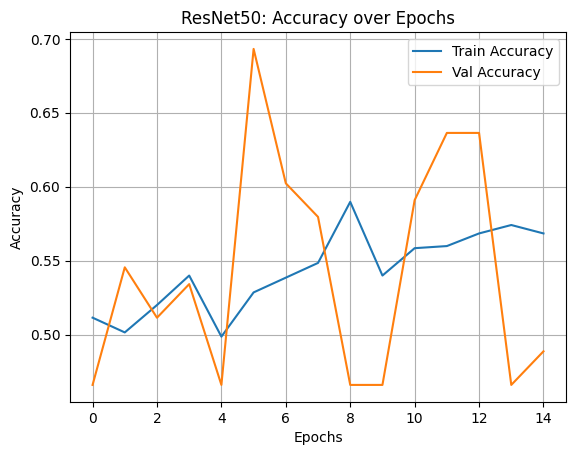

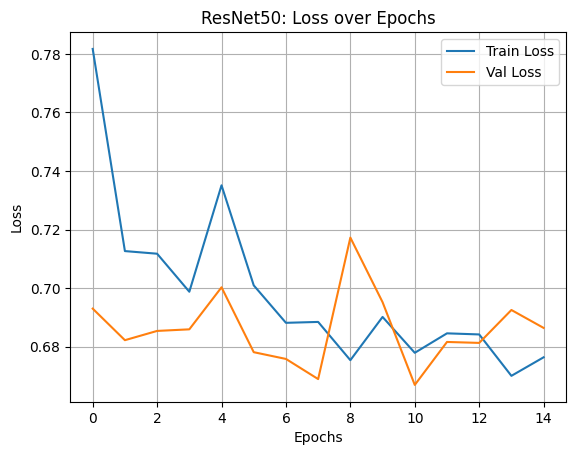

In [7]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("ResNet50: Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("ResNet50: Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4347 - loss: 0.7273
Test Accuracy: 43.18%


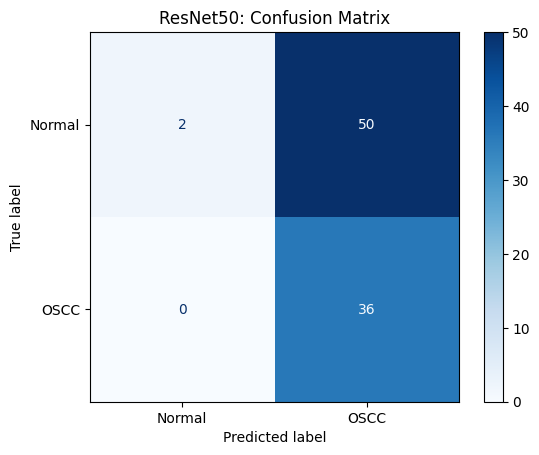


Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.04      0.07        52
        OSCC       0.42      1.00      0.59        36

    accuracy                           0.43        88
   macro avg       0.71      0.52      0.33        88
weighted avg       0.76      0.43      0.29        88



In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'OSCC'])
disp.plot(cmap='Blues')
plt.title("ResNet50: Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Normal", "OSCC"]))
